<a href="https://colab.research.google.com/github/maique-batista/maique-batista/blob/circleci-project-setup/CalcNum03_Maicon%20Batista%20da%20Silba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A estimativa da população do Brasil em 1910 é aproximadamente 23828021.


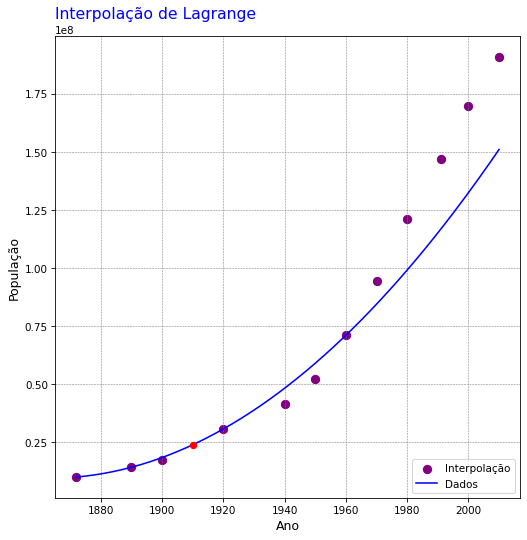

In [ ]:
#Questão 1
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

anos = [1872, 1890, 1900, 1920, 1940, 1950, 1960, 1970, 1980, 1991, 2000, 2010]
populacao = [9930478, 14333915, 17438434, 30635605, 41236315, 51944397, 70992343, 94506583, 121150573, 146917459, 169590693, 190755799]

def lagrange_interpola(x, y):
  polinomioL = lagrange(x, y)
  return polinomioL

ano_estimado = 1910

polinomio = lagrange_interpola(anos[:9][::3], populacao[:9][::3])

populacao_1910 = polinomio(ano_estimado)
print(f"A estimativa da população do Brasil em {ano_estimado:.0f} é aproximadamente {populacao_1910:.0f}.")

passo = 1
x_lista = np.arange(min(anos), max(anos) + passo, passo)
y_lista = [polinomio(xi) for xi in x_lista]
figura = plt.figure(figsize=(8, 8), dpi=75)
fonte = {'color': 'blue', 'size': 15}
plt.scatter(anos, populacao, marker='.', c='purple', s=250)
plt.plot(x_lista, y_lista, 'b-')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('População', fontsize=12)
plt.title('Interpolação de Lagrange', fontdict=fonte, loc='left')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend(['Interpolação', 'Dados'], loc="lower right")
plt.plot(ano_estimado, populacao_1910, 'ro') # Inclui o ponto estimado em 1910
plt.show()


O valor estimado do Bitcoin em 11/02/2023 é de $-536.2


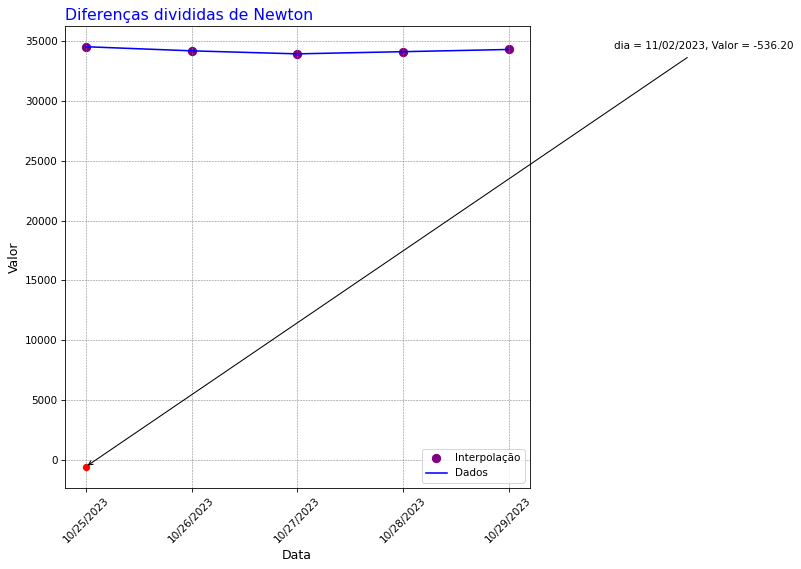

In [ ]:
#Quesão 2
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

data = '11/02/2023'

def data_para_inteiro(data, data_referencia):
  data_obj = datetime.strptime(data, '%m/%d/%Y')
  data_referencia_obj = datetime.strptime(data_referencia, '%m/%d/%Y')
  diferenca = (data_obj - data_referencia_obj).days
  return diferenca

data_referencia = '10/25/2023'
inteiro = data_para_inteiro(data, data_referencia)

datas = ['10/25/2023', '10/26/2023', '10/27/2023', '10/28/2023', '10/29/2023']
valores = [34496.8, 34153.7, 33901.8, 34082.8, 34267.3]

datas_int = np.arange(len(datas))

def calcular_coeficientes(x, y):
  n = len(x)
  coef = np.zeros((n, n))
  for i in range(n):
    coef[i][0] = y[i]
    for j in range(1, n):
      for i in range(n - j):
        coef[i][j] = (coef[i + 1][j - 1] - coef[i][j - 1]) / (x[i + j] - x[i])
  return coef

def interpolacao_newton(x, y, x_estimado, coef):
  n = len(x)
  resultado = 0
  temp = 1
  for i in range(n):
    resultado += coef[0][i] * temp
    temp *= x_estimado - x[i]
  return resultado


coef = calcular_coeficientes(datas_int, valores)

valor_estimado = interpolacao_newton(datas_int, valores, inteiro, coef)

print(f'O valor estimado do Bitcoin em {data} é de ${valor_estimado:.1f}')

x_estimados = np.arange(datas_int[0], datas_int[-1] + 1, 1)
y_estimados = [interpolacao_newton(datas_int, valores, x, coef) for x in x_estimados]
figura = plt.figure(figsize=(8, 8), dpi=75)
fonte = {'color': 'blue', 'size': 15}
plt.scatter(datas_int, valores, marker='.', c='purple', s=250)
plt.plot(x_estimados, y_estimados, 'b-')
plt.plot(data, valor_estimado, 'ro', label=f'Estimado em {data}: {valor_estimado:.1f}')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.title('Diferenças divididas de Newton', fontdict=fonte, loc='left')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend(['Interpolação', 'Dados'], loc="lower right")

labels = [datas[int(x)] for x in x_estimados]
plt.xticks(x_estimados, labels, rotation=45)
plt.annotate(f'dia = {data}, Valor = {valor_estimado:.2f}',
xy=(data, valor_estimado),
xytext=(max(datas_int) + 1, max(valores) - 200),
arrowprops=dict(arrowstyle='->'),
bbox=dict(boxstyle='round,pad=0.5', edgecolor='none', facecolor='white'))
plt.show()


Valor em t = 40 s é 1437.0511111111246 m/s


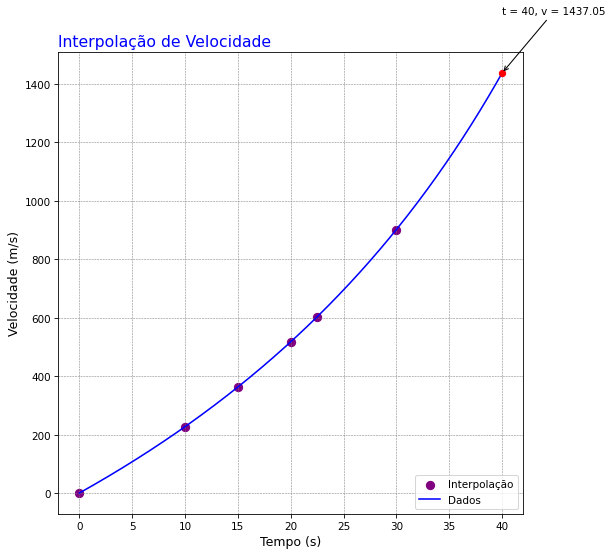

In [ ]:
#Questão 3
import numpy as np
import matplotlib.pyplot as plt

x = [0, 10, 15, 20, 22.5, 30]
y = [0.0, 227.04, 362.78, 517.35, 602.97, 901.67]

valor_interpolado = 40

def newton_regressiva(x, y, valor_interpolado):
  n = len(x)

  soma = 0
  for i in range(n):
    termo = y[i]
    for j in range(n):
      if j != i:
        termo *= (valor_interpolado - x[j]) / (x[i] - x[j])
    soma += termo
  return soma

n = 6

t = valor_interpolado
v = newton_regressiva(x, y, valor_interpolado)
print("\nValor em t =", t, "s é", v, "m/s")

passo = 0.1
x_lista = np.arange(min(x), valor_interpolado + passo, passo)
y_lista = [newton_regressiva(x, y, xi) for xi in x_lista]
figura = plt.figure(figsize=(8, 8), dpi=75)
fonte = {'color': 'blue', 'size': 15}
plt.scatter(x, y, marker='.', c='purple', s=250)
plt.plot(x_lista, y_lista, 'b-')
plt.plot(t, v, 'ro')
plt.xlabel('Tempo (s)', fontsize=12)
plt.ylabel('Velocidade (m/s)', fontsize=12)
plt.title('Interpolação de Velocidade', fontdict=fonte, loc='left')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend(['Interpolação', 'Dados'], loc="lower right")
plt.annotate(f't = {t}, v = {v:.2f}', xy=(t, v), xytext=(t, v + 200),arrowprops=dict(arrowstyle='->'))
plt.show()
